# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   | X       |
|------------|---------|
| Tushit Jain  | 6233384 |
| Lukáš Kubis  | 6207618 |
| Xianfei Kong  | XXXXXXX |
| Alex Ion  | 6138101 |

#### Imports

In [1]:
from scipy.spatial.distance import euclidean

"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData
from Visualizer import Visualizer

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 2

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 3

<div style="background-color:#f1be3e">

_Write your answer here._

### 1.2 Genetic Algorithm

In [2]:
# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    """
    def __init__(self, generations, pop_size, mutation_prob, crossover_prob):
        self.generations = generations
        self.pop_size = pop_size
        self.mutation_prob = mutation_prob
        self.crossover_prob = crossover_prob
    
    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        tsp_data.build_distance_lists()
        self.distance_matrix = tsp_data.distances
        self.chromosome_length = len(self.distance_matrix)
        self.population = self.initialise_population(self.chromosome_length)
        pass

    """
    This method creates the initial population of size pop_size.
    Each individual's chromosome is an array containing products 0 to pop_size - 1 in a random order.
    @return the entire initial population as an array contianing chromosomes of each individiual.
    """
    def initialise_population(self, n):
        return [random.sample(range(n), n) for _ in range(self.pop_size)]
    
    """
    This method is responsible for adding mutations to an individual.
    Here, a mutation is swapping two indecies, which corresponds with swapping positions of two products in a path.
    @param individual: the individual we want to mutate.
    @return the individual which may or may not have been mutated.
    """
    def mutate(self, individual):
        if random.random() < self.mutation_prob:
            i, j = random.sample(range(self.chromosome_length), 2)
            individual[i], individual[j] = individual[j], individual[i]
        return individual


    """
    This method applies ordered crossover to two parents resulting in two new individuals.
    @return two new individuals based on the parents genes
    """
    def ordered_crossover(self, parent1, parent2):
        start_index, end_index = sorted(random.sample(range(self.chromosome_length), 2))
        child1 = [-1] * self.chromosome_length
        child2 = [-1] * self.chromosome_length
        child1[start_index:end_index] = parent1[start_index:end_index]
        child2[start_index:end_index] = parent2[start_index:end_index]
        parent1_pointer = end_index
        parent2_pointer = end_index
        filled_genes_child1 = set(child1[start_index:end_index])
        filled_genes_child2 = set(child2[start_index:end_index])
        for i in range(self.chromosome_length - (end_index - start_index)):
            child1_index = (end_index + i) % self.chromosome_length
            while parent2[parent2_pointer % self.chromosome_length] in filled_genes_child1:
                parent2_pointer += 1
            child1[child1_index] = parent2[parent2_pointer % self.chromosome_length]
            filled_genes_child1.add(parent2[parent2_pointer % self.chromosome_length])
        for j in range(self.chromosome_length - (end_index - start_index)):
            child2_index = (end_index + j) % self.chromosome_length
            while parent1[parent1_pointer % self.chromosome_length] in filled_genes_child2:
                parent1_pointer += 1
            child2[child2_index] = parent1[parent1_pointer % self.chromosome_length]
            filled_genes_child2.add(parent1[parent1_pointer % self.chromosome_length])
        return child1, child2



    """
    Calculates the fitness of a given individual. Here the fitness is defined as 1/sum of pairwise distances.
    @param individual: the individual for which we are calculating the fitness
    @return the fitness of this individual
    """
    def fitness(self, individual):
        total_distance = 0
        current_node_index = 0
        next_node_index = 1
        while(next_node_index < self.chromosome_length):
            current_product = individual[current_node_index]
            next_product = individual[next_node_index]
            total_distance += self.distance_matrix[current_product][next_product]
            current_node_index += 1
            next_node_index += 1
        return 1/total_distance
    

    """
    This method is responsible for implementing binary tournament selection on the population.
    It picks two candidates at random and returns the individual with the higher fitness.
    @return the chosen candidate
    """
    def binary_tournament_selection(self):
        candidate_one_index, candidate_two_index = random.sample(range(self.pop_size), 2)
        candidate_one = self.population[candidate_one_index]
        candidate_two = self.population[candidate_two_index]
        if (self.fitness(candidate_one) > self.fitness(candidate_two)):
            return candidate_one
        else:
            return candidate_two


#### Question 4

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 5

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 6

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 7

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 8

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 9

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10

In [3]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 20
generations = 20
random.seed(50)
mutation_prob = 0.1
crossover_prob = 0.8
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size, mutation_prob, crossover_prob)

# Run optimzation and write to file
solution = ga.solve_tsp(tsp_data)
# tsp_data.write_action_file(solution, "./../data/tsp_solution.txt")

<div style="background-color:#f1be3e">

_Put your code extra blocks above (if any) and write your answer here._

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

<div style="">
The purpose of Ant Colony Optimization (ACO) is in general to solve optimization problems. It does this based on how real ants communicate, which is with the help of pheromones the deposit.
<br/>
<br/>
The usual settings where ACO is used are tasks in which the artificial ants have to find the shortest path to some goal. For example, the Travelling Salesman Problem, in which the goal is to find the shortest path such that all cities are visited exactly once.

#### Question 12

<div style="">

One 'topographical' feature of a maze that can make it difficult for an ant to find the exit is the number of dead ends between the starting point and the exit point. Since ants choose their paths probabilistically, if we increase the number of ways that the ants can go without reaching the end, we decrease the chance of them actually finding the exit. <br/>
<br/>
Another such feature is the overall complexity/size of the maze. This is because the more complex the maze is, the more iterations and ants the algorithm requires to eventually find the solution. If the maze is too difficult, the algorithm might not be feasible, and in the real world for too complex problems the basic algorithm is rarely used for very complex tasks.

#### Question 13

<div style="">

The equation used for the amount of dropped pheromone is:
$ \tau _{ij} = Q*\frac{1}{L^{k}} $ <br/>
Where $Q$ is a set value, and $ L^{k} $ is the length of route k.<br/>
<br/>
Ants need to drop pheromones because the next generation uses the amount of pheromones on each cell to calculate their probabilities and pick a path. As such, each ant in a generation needs to drop pheromones such that the next generation can pick a path next. In addition, without any pheromones added, the next generation would be picking randomly and then no real optimization would take place, the behavior of the ants being closer to a random walk than actually trying to find a path.

#### Question 14

<div style="">

The equation used is:
 $ \tau _{ij}=(1-\rho)*\tau_{ij} + \sum_{k=1}^{m}\Delta\tau_{ij}^{k} $ <br/>
 Where, $\rho$ is the evaporation constant (which usually has a value equal to 0.1, but can be changed), $\tau_{ij}$ is the amount of pheromones currently on the path, and $\sum_{k=1}^{m}\Delta\tau_{ij}^{k}$ is the total amount of pheromones added on this path.<br/> <br/>
 The amount of pheromones that evaporate is dependent on the value of $\rho$, since it dictates how much of the current amount of pheromones remains. In our implementation, we set the constant to 0.1, and as such we will have 0.1 of the pheromone evaporate before having more added by the other ants. <br/> <br/>
 The purpose of pheromone evaporation is making sure that the shortest (or the closest path to the shortest) remains at the end. This works because the longer paths will eventually have pheromones evaporate off of them, since ants will get to the shorter ones faster, and thus deposit more pheromones on the shorter ones.

### 2.3 Implementing the Ant Algorithm

In [6]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """
    Constructor of a StandardAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification, alpha, beta, max_iter):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.alpha = alpha
        self.beta = beta
        self.rand = random
        self.max_iter = max_iter

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        last_visited = (self.start.x, self.start.y)
        step = 0
        # Loop until we find the exit or reach maximum steps (to prevent infinite loops)
        while self.current_position != self.end and step < self.max_iter:  # Adjust the maximum steps as needed
            step += 1
            #print("-----------------------------")
            # Get surrounding pheromones and possible directions
            surrounding = self.maze.get_surrounding_pheromone(self.current_position)
            directions = [Direction.east, Direction.north, Direction.west, Direction.south]
            probabilities = []
            for direction in directions:
                neighbor = self.current_position.add_direction(direction)
                #print(f"For direction {direction}, we are in neighbor: ({neighbor.x}, {neighbor.y})")
                # Check if we are still in the maze, and it is not a wall, and we didn't visit it
                if (self.maze.in_bounds(neighbor)
                        and self.maze.walls[neighbor.x][neighbor.y] == 1.0
                        and (neighbor.x, neighbor.y) != last_visited):
                    #print(f"We append the surrounding pheromones ({surrounding.get(direction)})")
                    tau = surrounding.get(direction)**self.alpha
                    #euclidean = np.sqrt((neighbor.x - self.end.x) ** 2 + (neighbor.y - self.end.y) ** 2)
                    #eta = (1.0 / euclidean) ** self.beta
                    eta = (1.0 / 1.0) ** self.beta #distance in maze is just 1
                    probabilities.append(tau*eta + 0.1)
                else:
                    #print("We are outside the maze so append 0.0")
                    probabilities.append(0.0)

            total = sum(probabilities)
            #print(f"Total is {total}")
            if total == 0.0:
                return None #ant is stuck

            probabilities = [prob / total for prob in probabilities]
            #print(f"Probabilities are {probabilities}")
            next_direction = self.rand.choices(directions, weights=probabilities, k=1)[0]
            #print(f"We picked the next direction to be {next_direction}")
            next_position = self.current_position.add_direction(next_direction)

            route.add(next_direction)
            last_visited = (self.current_position.x, self.current_position.y)
            self.current_position = next_position
        if(step >= self.max_iter):
            return None #ant is stuck
        return route



In [7]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
from matplotlib import pyplot as plt


class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.pheromones = [[1.0] * self.length for _ in range(self.width)]
        self.initialize_pheromones()

    """
    Initialize pheromones on all tiles of the Maze
    """
    def initialize_pheromones(self):
        #self.pheromones = [[1]*self.length]*self.width
        self.pheromones = [[1.0] * self.length for _ in range(self.width)]

    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        deposit = q / len(route.get_route())
        position = route.get_start()
        for step in route.get_route():
            position = position.add_direction(step)
            if self.in_bounds(position):
                self.pheromones[position.x][position.y] += deposit

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        for r in routes:
            self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        for i in range(self.width):
            for j in range(self.length):
                self.pheromones[i][j] *= (1.0-rho)

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Returns a the amount of pheromones on the neighbouring positions (N/S/E/W)
    @param position: the coordinate where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates.
    """
    def get_surrounding_pheromone(self, position):
        n_pher = self.get_pheromone(position.add_direction(Direction.north))
        s_pher = self.get_pheromone(position.add_direction(Direction.south))
        e_pher = self.get_pheromone(position.add_direction(Direction.east))
        w_pher = self.get_pheromone(position.add_direction(Direction.west))
        return SurroundingPheromone(n_pher,s_pher,e_pher,w_pher)

    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the poition of interest
    @return the amount of pheromone at the specified poition
    """
    def get_pheromone(self, pos):
        if 0 <= pos.x < self.width:
            if 0 <= pos.y < self.length:
                return self.pheromones[pos.x][pos.y]
        return 0.0

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            
            #make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])
            
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

    def visualize_pheromones(self):
        grid = np.zeros((self.width, self.length))
        for x in range(self.width):
            for y in range(self.length):
                if self.walls[x][y] == 0:
                    grid[x][y] = -1  # wall
                else:
                    grid[x][y] = self.pheromones[x][y]

        grid = grid.T

        wall_mask = grid == -1
        zero_mask = (grid == 0.0) & ~wall_mask  # zero pheromone on accessible tiles
        pheromone_grid = np.where(wall_mask | zero_mask, np.nan, grid)

        fig, ax = plt.subplots(figsize=(6, 4))

        # Draw pheromone heatmap in green gradient
        im = ax.imshow(pheromone_grid, cmap='Greens', interpolation='nearest',
                    vmin=0, vmax=np.nanpercentile(pheromone_grid, 95))

        # Draw walls in black
        wall_display = np.where(wall_mask, 1.0, np.nan)
        ax.imshow(wall_display, cmap='gray', interpolation='nearest', vmin=0, vmax=1)

        # Draw zero pheromone tiles in red
        zero_display = np.where(zero_mask, 1.0, np.nan)
        ax.imshow(zero_display, cmap='autumn_r', interpolation='nearest', vmin=0, vmax=1)

        if self.start is not None:
            ax.plot(self.start.x, self.start.y, 'bs', markersize=10, label='Start')
        if self.end is not None:
            ax.plot(self.end.x, self.end.y, 'b*', markersize=12, label='End')

        plt.colorbar(im, ax=ax, label='Pheromone level')
        ax.set_title('Pheromone heatmap')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        if self.start is not None or self.end is not None:
            ax.legend()
        plt.tight_layout()
        plt.show()

In [31]:
import numpy as np
from matplotlib import pyplot as plt
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    @param stop_limit: the number of consecutive iterations without improvement in the shortest path before the algorithm stops
    @param max_iter: the maximum number of iterations for each ant to find a path (to prevent infinite loops)
    @param momentum: the momentum factor for the intelligent ant variant
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation, alpha, beta, stop_limit, max_iter=1000, momentum=1.1):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.alpha = alpha
        self.beta = beta
        self.evaporation = evaporation
        self.stop_limit = stop_limit
        self.max_iter = max_iter
        self.momentum = momentum

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @param intelligent_ant: flag indicating whether to use the intelligent ant variant
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification, intelligent_ant):
        self.maze.reset()
        shortest_route = Route(path_specification.get_start())
        shortest_length = float("inf")
        iterations_without_improvement = 0
        for g in range(self.generations):
            routes = []
            shortest_route_found = False
            for a in range(self.ants_per_gen):
                if intelligent_ant:
                    ant = IntelligentAnt(self.maze, path_specification, self.alpha, self.beta, self.momentum)
                    cur_route, negative_pheromone_tiles = ant.find_route()
                    for tile in negative_pheromone_tiles:
                        self.maze.pheromones[tile[0]][tile[1]] = 0.0
                else:
                    ant = StandardAnt(self.maze, path_specification, self.alpha, self.beta, self.max_iter)
                    cur_route = ant.find_route()
                if cur_route is not None:
                    routes.append(cur_route)
                    cur_length = len(cur_route.get_route())
                    if cur_length < shortest_length:
                        shortest_length = cur_length
                        shortest_route = cur_route
                        shortest_route_found = True
            # Update pheromones
            self.maze.evaporate(self.evaporation)
            self.maze.add_pheromone_routes(routes, self.q)

            if shortest_route_found:
                iterations_without_improvement = 0
            else:
                iterations_without_improvement += 1
    
            # Convergence criterion
            if iterations_without_improvement > self.stop_limit:
                break
        return shortest_route


Ready reading maze file ./../data/easy_maze.txt
Start: 0, 0 End: 24, 14
Time taken: 36.553
Route size: 38


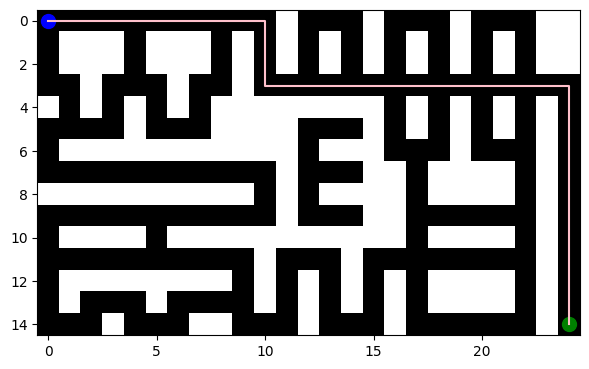

Pheromone levels at the end:


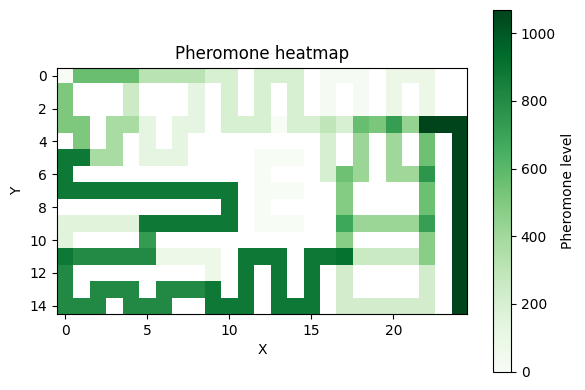

In [40]:
# Please keep your parameters for the ACO easily changeable here
ants_per_gen = 200
no_gen = 1200
q = 100
evap = 0.2
max_iter = 50
alpha = 1
beta = 2
stop_limit = 40
momentum = 1.1

# Construct the optimization objects
maze = Maze.create_maze("./../data/easy_maze.txt")
spec = PathSpecification.read_coordinates("./../data/easy_coordinates.txt")
#maze.visualize_pheromones(start=spec.get_start(), end=spec.get_end())
path_spec_string = spec.__str__()
print(path_spec_string)
aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, momentum)

start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec, True)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))
Visualizer.visualize_individual_path(maze, shortest_route, spec)
print("Pheromone levels at the end:")
maze.visualize_pheromones()


shortest_route.write_to_file("./../data/easy_solution.txt")

### 2.4 Upgrading Your Ants with Intelligence

#### Question 15

In [33]:
# Class that represents the intelligent Ant
class IntelligentAnt:

    """
    Constructor of an IntelligentAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification, alpha, beta, momentum=1.1):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random
        self.alpha = alpha
        self.beta = beta
        self.momentum = momentum

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """

    def find_route(self):
        route = Route(self.start)
        negative_pheromone_tiles = []
        dfs_stack = []
        visited = set()
        last_visited = (self.start.x, self.start.y)
        visited.add(last_visited)
        current_direction = None
        num_steps = 0
        # Loop until we find the exit
        while self.current_position != self.end:
            # Get surrounding pheromones and possible directions
            surrounding = self.maze.get_surrounding_pheromone(self.current_position)
            directions = [Direction.east, Direction.north, Direction.west, Direction.south]
            probabilities = []
            loop_found = False

            for direction in directions:
                neighbor = self.current_position.add_direction(direction)
                
                #check for the possibility of a loop
                if ((neighbor.x, neighbor.y) in visited
                    and (neighbor.x, neighbor.y) != last_visited):
                        loop_found = True
                        
                # Check if we are still in the maze, and it is not a wall, and we didn't visit it
                if (self.maze.in_bounds(neighbor)
                        and self.maze.walls[neighbor.x][neighbor.y] == 1.0
                        and (neighbor.x, neighbor.y) not in visited):
                    tau = surrounding.get(direction)**self.alpha
                    #euclidean = np.sqrt((neighbor.x - self.end.x) ** 2 + (neighbor.y - self.end.y) ** 2)
                    #eta = (1.0 / euclidean) ** self.beta
                    eta = (1.0 / 1.0) ** self.beta #distance in maze is just 1

                    momentum_bonus = self.momentum if direction == current_direction else 1.0
                    probabilities.append(tau*eta*momentum_bonus + 0.1)
                else:
                    probabilities.append(0.0)

            total = sum(probabilities)
            while total == 0.0:
                self.current_position, probabilities, current_direction, prev_num_steps, visited = dfs_stack.pop()

                if(not loop_found):                    
                    # leaving negative pheromone on the tile to avoid other ants to get stuck in the same deadend
                    prev_next_position = self.current_position.add_direction(current_direction)
                    negative_pheromone_tiles.append((prev_next_position.x, prev_next_position.y))
                
                # backtrack to the position before the loop/dead end started
                for i in range(num_steps - prev_num_steps):
                    route.remove_last()
                num_steps = prev_num_steps
                
                # if all probabilities are zero, no path from current intersection leads to the exit, so it's a dead end.
                total = sum(probabilities)
                if(total == 0.0):
                    loop_found = False
            
            probabilities = [prob / total for prob in probabilities]
            next_direction = self.rand.choices(directions, weights=probabilities, k=1)[0]

            # avoid going back to the same position we just came from to prevent immediate loops
            probabilities[next_direction.value] = 0.0
            
            # storing the position and probabilities for backtracking
            if(any(p > 0 for p in probabilities)):
                dfs_stack.append((self.current_position, probabilities, next_direction, num_steps, set(visited)))

            route.add(next_direction)

            # moving to the next position
            next_position = self.current_position.add_direction(next_direction)
            last_visited = (self.current_position.x, self.current_position.y)
            self.current_position = next_position
            visited.add((self.current_position.x, self.current_position.y))

            # updating the last visited position and current direction for loop detection and momentum
            current_direction = next_direction
            num_steps += 1

        return (route, negative_pheromone_tiles)



==================== dead_end_maze.txt ====================
Ready reading maze file ./../data/dead_end_maze.txt
========Standard Ant:
Time taken: 0.071
Route size: 12


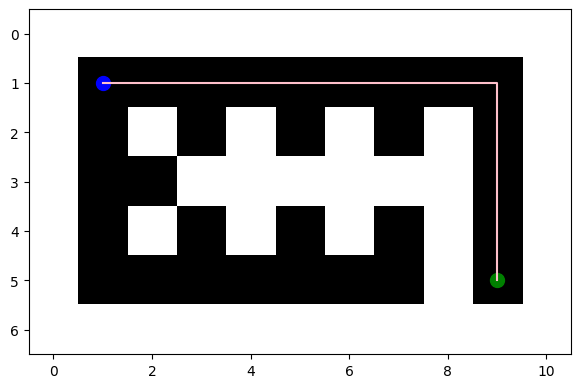

Pheromone levels at the end:


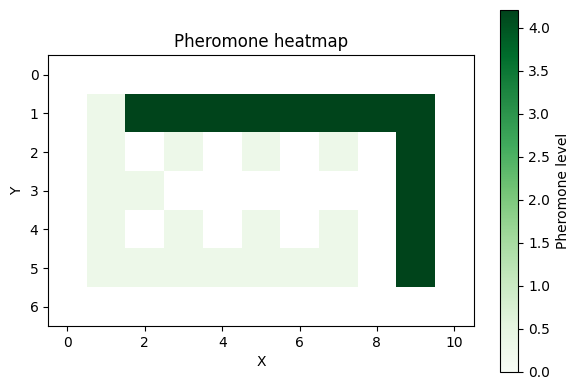


========Intelligent Ant:
Time taken: 0.306
Route size: 12


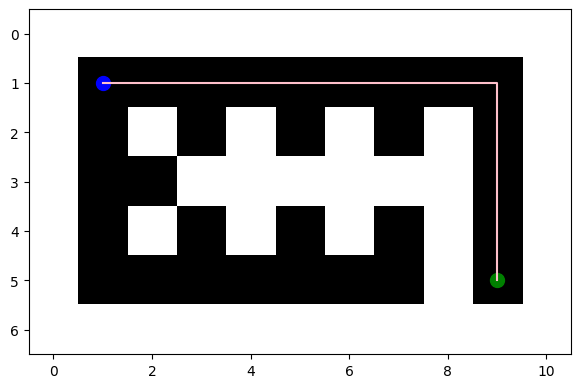

Pheromone levels at the end:


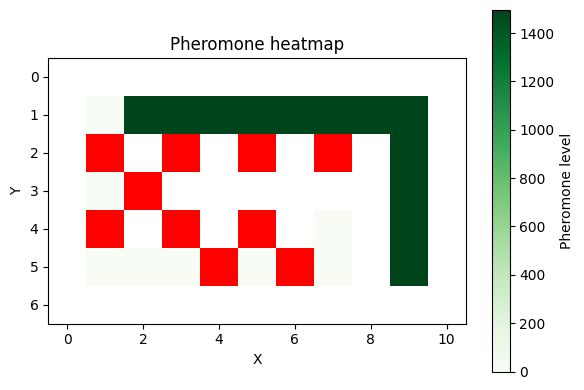


==================== loop_maze.txt ====================
Ready reading maze file ./../data/loop_maze.txt
========Standard Ant:
Time taken: 0.283
Route size: 12


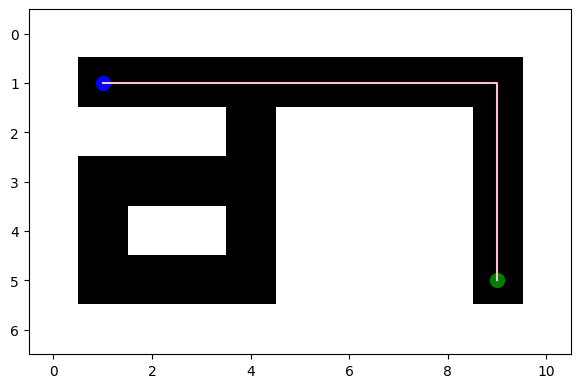

Pheromone levels at the end:


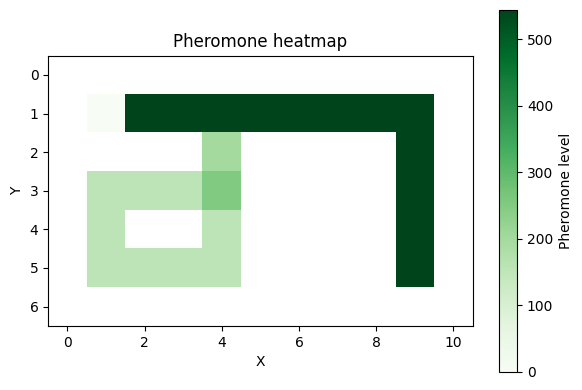


========Intelligent Ant:
Time taken: 0.325
Route size: 12


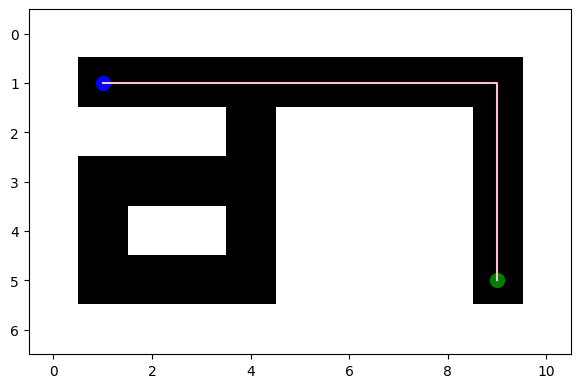

Pheromone levels at the end:


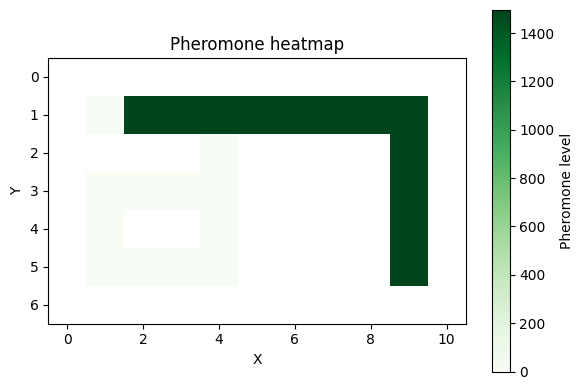


==================== dead_end_loop_maze.txt ====================
Ready reading maze file ./../data/dead_end_loop_maze.txt
========Standard Ant:
Time taken: 0.184
Route size: 12


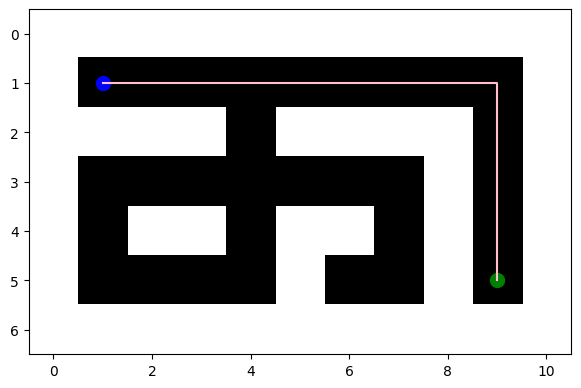

Pheromone levels at the end:


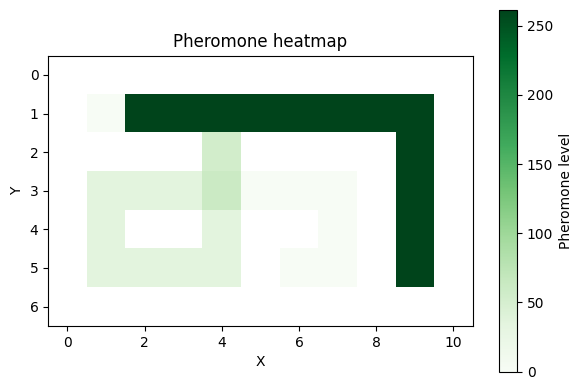


========Intelligent Ant:
Time taken: 0.387
Route size: 12


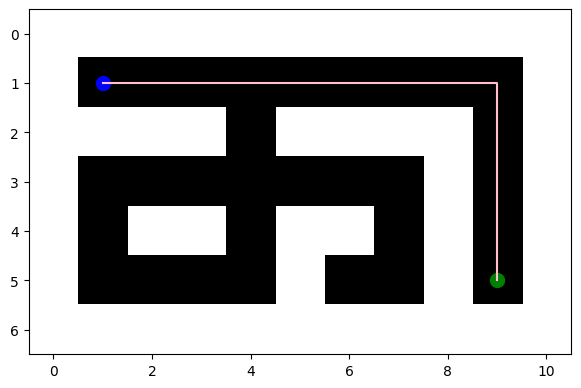

Pheromone levels at the end:


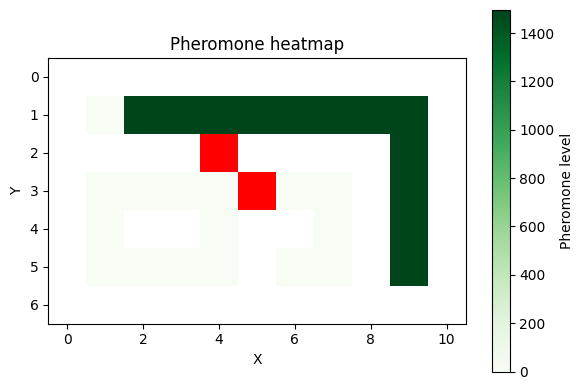

In [35]:
test_mazes = [
    ("dead_end_maze.txt", "dead_end_coordinates.txt"),
    ("loop_maze.txt", "loop_coordinates.txt"),
    ("dead_end_loop_maze.txt", "dead_end_loop_coordinates.txt"),
]

ants_per_gen = 50
no_gen = 20
q = 50
evap = 0.1
max_iter = 100
alpha = 1
beta = 2
stop_limit = 10
momentum = 1.2


for maze_file, coords_file in test_mazes:
    print(f"\n==================== {maze_file} ====================")
    maze = Maze.create_maze(f"./../data/{maze_file}")
    spec = PathSpecification.read_coordinates(f"./../data/{coords_file}")
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, momentum)

    print("========Standard Ant:")
    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec, False)

    print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
    print("Route size: " + str(shortest_route.size()))
    Visualizer.visualize_individual_path(maze, shortest_route, spec)
    print("Pheromone levels at the end:")
    maze.visualize_pheromones()
    
    print("\n========Intelligent Ant:")
    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec, True)

    print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
    print("Route size: " + str(shortest_route.size()))
    Visualizer.visualize_individual_path(maze, shortest_route, spec)
    print("Pheromone levels at the end:")
    maze.visualize_pheromones()


==================== momentum: 1.0 ====================
Ready reading maze file ./../data/open_area_maze.txt
 Generation 1/100 | No improvement: 0/30
  ↳ New shortest route: 30 steps
 Generation 32/100 | No improvement: 30/30
Time taken: 7.02
Route size: 30

==================== momentum: 1.5 ====================
Ready reading maze file ./../data/open_area_maze.txt
 Generation 1/100 | No improvement: 0/30
  ↳ New shortest route: 36 steps
 Generation 6/100 | No improvement: 4/30
  ↳ New shortest route: 34 steps
 Generation 10/100 | No improvement: 3/30
  ↳ New shortest route: 32 steps
 Generation 34/100 | No improvement: 23/30
  ↳ New shortest route: 28 steps
 Generation 65/100 | No improvement: 30/30
Time taken: 13.317
Route size: 28

==================== momentum: 2.0 ====================
Ready reading maze file ./../data/open_area_maze.txt
 Generation 1/100 | No improvement: 0/30
  ↳ New shortest route: 30 steps
 Generation 23/100 | No improvement: 21/30
  ↳ New shortest route: 28 s

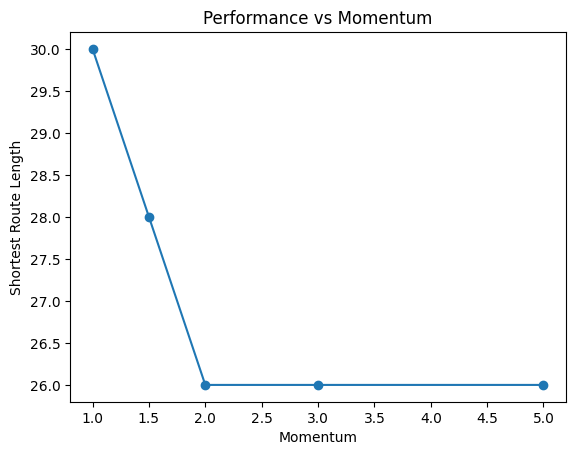

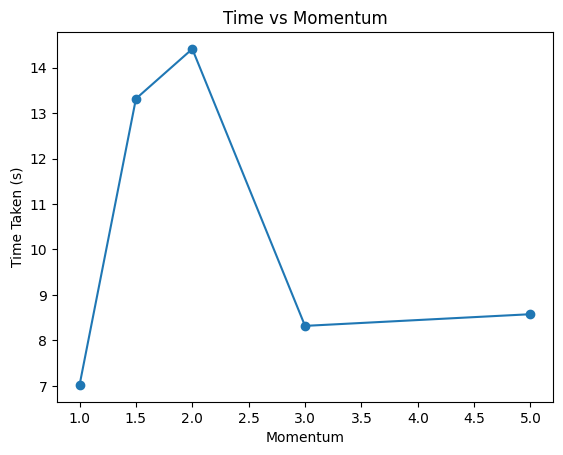

In [226]:
momentums = [1.0, 1.5, 2.0, 3.0, 5.0]

ants_per_gen = 50
no_gen = 100
q = 500
evap = 0.1
max_iter = 200
alpha = 1
beta = 2
stop_limit = 30

results = []
for m in momentums:
    print(f"\n==================== momentum: {m} ====================")
    maze = Maze.create_maze("./../data/open_area_maze.txt")
    spec = PathSpecification.read_coordinates("./../data/open_area_coordinates.txt")
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, m)

    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec, True)
    elapsed = (int(round(time.time() * 1000)) - start_time) / 1000.0
    print("Time taken: " + str(elapsed))
    print("Route size: " + str(shortest_route.size()))
    results.append((shortest_route.size(), elapsed))

# Plot results
lengths = [r[0] for r in results]
times = [r[1] for r in results]

plt.figure()
plt.plot(momentums, lengths, marker='o')
plt.xlabel("Momentum")
plt.ylabel("Shortest Route Length")
plt.title("Performance vs Momentum")
plt.show()

plt.figure()
plt.plot(momentums, times, marker='o')
plt.xlabel("Momentum")
plt.ylabel("Time Taken (s)")
plt.title("Time vs Momentum")
plt.show()

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

### 2.5 Parameter Optimization

#### Question 16

In [228]:
def optimize_hyperparameter(maze_file, coords_file, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, m):
    maze = Maze.create_maze(f"./../data/{maze_file}")
    spec = PathSpecification.read_coordinates(f"./../data/{coords_file}")
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, m)

    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec, True)
    time_taken = (int(round(time.time() * 1000)) - start_time) / 1000.0
        
    return (shortest_route.size(), time_taken)

In [229]:
def visualize_hyperparameter_results(param_name, param_values, results):
    lengths = [r[1] for r in results]
    times = [r[2] for r in results]

    plt.figure()
    plt.plot(param_values, lengths, marker='o')
    plt.xlabel(param_name)
    plt.ylabel("Shortest Route Length")
    plt.title("Performance vs " + param_name)
    plt.show()

    plt.figure()
    plt.plot(param_values, times, marker='o')
    plt.xlabel(param_name)
    plt.ylabel("Time Taken (s)")
    plt.title("Time vs " + param_name)
    plt.show()

In [237]:
test_mazes = [
    ("easy_maze.txt", "easy_coordinates.txt"),
    ("medium_maze.txt", "medium_coordinates.txt"),
    ("hard_maze.txt", "hard_coordinates.txt"),
]
default_ants_per_gen = 50
default_no_gen = 500
default_q = 500
default_evap = 0.1
default_alpha = 1
default_beta = 2
default_stop_limit = 40
default_momentum = 1.5
default_max_iter = 1000 # we don't need to optimize this parameter as the intelligent ant doesn't not use it.

ants_per_gen = [20, 50, 100, 200]
no_gen = [100, 250, 500, 1000]
q = [100, 200, 500, 1000]
evap = [0.01, 0.1, 0.2]
alpha = [1, 2, 5]
stop_limit = [20, 40, 60]
momentum = [1.0,1.5, 3.0, 5.0]


for maze_file, coords_file in test_mazes:
    print("==================== {maze_file} ====================")

    print("======== Optimizing Ants per Generation:")
    results = []
    for a in ants_per_gen: 
        results.append(optimize_hyperparameter(maze_file, coords_file, a, default_no_gen, default_q, default_evap, default_alpha, default_beta, default_stop_limit, default_max_iter, default_momentum))
    visualize_hyperparameter_results("Ants per Generation", ants_per_gen, results)

    print("======== Optimizing Number of Generations:")
    results = []
    for g in no_gen: 
        results.append(optimize_hyperparameter(maze_file, coords_file, default_ants_per_gen, g, default_q, default_evap, default_alpha, default_beta, default_stop_limit, default_max_iter, default_momentum))
    visualize_hyperparameter_results("Number of Generations", no_gen, results)

    print("======== Optimizing Q:")
    results = []
    for qv in q: 
        results.append(optimize_hyperparameter(maze_file, coords_file, default_ants_per_gen, default_no_gen, qv, default_evap, default_alpha, default_beta, default_stop_limit, default_max_iter, default_momentum))
    visualize_hyperparameter_results("Q", q, results)

    print("======== Optimizing Evaporation Rate:")
    results = []
    for ev in evap: 
        results.append(optimize_hyperparameter(maze_file, coords_file, default_ants_per_gen, default_no_gen, default_q, ev, default_alpha, default_beta, default_stop_limit, default_max_iter, default_momentum))
    visualize_hyperparameter_results("Evaporation Rate", evap, results)

    print("======== Optimizing Alpha:")
    results = []
    for a in alpha: 
        results.append(optimize_hyperparameter(maze_file, coords_file, default_ants_per_gen, default_no_gen, default_q, default_evap, a, default_beta, default_stop_limit, default_max_iter, default_momentum))
    visualize_hyperparameter_results("Alpha", alpha, results)

    print("======== Optimizing Stop Limit:")
    results = []
    for sl in stop_limit: 
        results.append(optimize_hyperparameter(maze_file, coords_file, default_ants_per_gen, default_no_gen, default_q, default_evap, default_alpha, default_beta, sl, default_max_iter, default_momentum))
    visualize_hyperparameter_results("Stop Limit", stop_limit, results)

    print("======== Optimizing Momentum:")
    results = []
    for m in momentum: 
        results.append(optimize_hyperparameter(maze_file, coords_file, default_ants_per_gen, default_no_gen, default_q, default_evap, default_alpha, default_beta, default_stop_limit, default_max_iter, m))
    visualize_hyperparameter_results("Momentum", momentum, results)

==================== {maze_file} ====================
======== Optimizing Ants per Generation:
Ready reading maze file ./../data/easy_maze.txt
Ready reading maze file ./../data/easy_maze.txt
Ready reading maze file ./../data/easy_maze.txt


KeyboardInterrupt: 

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.6 The Final Route

#### Question 18

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.7 Synthesis

#### Question 19

In [9]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 1
no_gen = 1
q = 1000
evap = 0.1

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
ga = GeneticAlgorithm(generations, population_size)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

Ready reading maze file ./../data/hard_maze.txt


TypeError: AntColonyOptimization.__init__() missing 2 required positional arguments: 'alpha' and 'beta'

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**